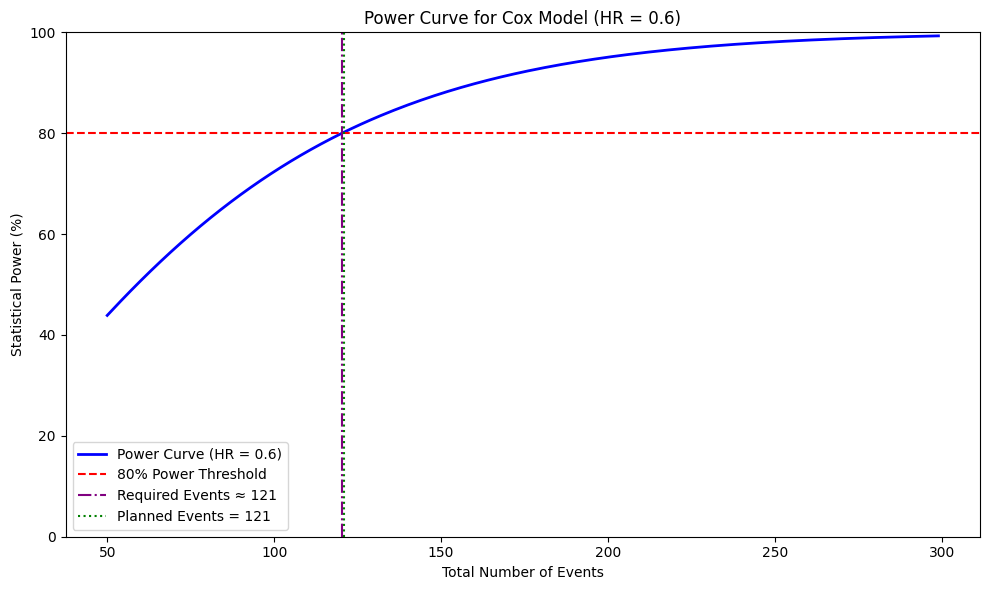

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
q0 = 0.5   # allocation to control
q1 = 0.5   # allocation to treatment
HR = 0.6   # hazard ratio
total_events_target = 121  # planned events
alpha = 0.05

# Z values
z_alpha = norm.ppf(1 - alpha / 2)
z_beta = norm.ppf(0.80)

# Event counts to explore
event_counts = np.arange(50, 300, 1)
powers = []

# Calculate power using Schoenfeld formula
for events in event_counts:
    se = 1 / np.sqrt(events * q0 * q1)
    z_effect = np.log(HR) / se
    power = 1 - (norm.cdf(z_effect - z_alpha) + (1 - norm.cdf(-z_effect - z_alpha)))
    powers.append(power * 100)

# Required events for 80% power
required_events = ((z_alpha + z_beta) ** 2) / ((np.log(HR)) ** 2 * q0 * q1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(event_counts, powers, color='blue', label=f'Power Curve (HR = {HR})', linewidth=2)
plt.axhline(80, color='red', linestyle='--', label='80% Power Threshold')
plt.axvline(required_events, color='purple', linestyle='-.',
            label=f'Required Events ≈ {int(np.ceil(required_events))}')
plt.axvline(total_events_target, color='green', linestyle=':',
            label=f'Planned Events = {total_events_target}')

plt.xlabel('Total Number of Events')
plt.ylabel('Statistical Power (%)')
plt.title('Power Curve for Cox Model (HR = 0.6)')
plt.grid(False)
plt.ylim(0, 100)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Tidy the summary table
# -----------------------------
df = summary_tables.copy()

# Create Model and Block columns from the "Variable" text
df['Model'] = df['Variable'].where(df['Variable'].str.contains(r'^Model', na=False))
df['Block'] = df['Variable'].where(df['Variable'].str.contains(r'^Block', na=False))

df['Model'] = df['Model'].ffill()
df['Block'] = df['Block'].ffill()

# Drop the rows that are just labels (Model, Block) or Intercept
mask_keep = ~df['Variable'].str.match(r'^Model', na=False) \
             & ~df['Variable'].str.match(r'^Block', na=False) \
             & ~df['Variable'].str.match(r'^Intercept$', na=False)

df = df[mask_keep].copy()

# -----------------------------
# 2. Parse OR and 95% CI
# -----------------------------
# Your columns look like: 'Odds Ratio' and '95% CI' as "[0.11 - 0.16]"
df['OR'] = df['Odds Ratio'].astype(float)

# Extract lower & upper from the CI string
ci = df['95% CI'].astype(str)

df['CI_lower'] = ci.str.extract(r'\[\s*([0-9\.Ee\-]+)\s*-\s*')[0].astype(float)
df['CI_upper'] = ci.str.extract(r'-\s*([0-9\.Ee\-]+)\s*\]')[0].astype(float)

# Optional: keep a smaller set of variables (e.g. pain, sex, age, symptoms)
# var_keep = ['Pain-Related Limitations', 'Sex', 'Age', 'Depressive Symptoms', 'Anxiety Symptoms']
# df = df[df['Variable'].isin(var_keep)].copy()

# Sort nicely: by Model, then Block, then Variable
df = df.sort_values(['Model', 'Block', 'Variable'], ascending=[True, True, True])

# -----------------------------
# 3. Create labels & positions
# -----------------------------
df['label'] = df['Model'] + ' | ' + df['Block'] + ' | ' + df['Variable']

# y positions: 0, 1, 2, ...
y_pos = np.arange(len(df))[::-1]  # reverse so first row is at top

# -----------------------------
# 4. Plot forest on log scale
# -----------------------------
fig, ax = plt.subplots(figsize=(9, max(6, len(df) * 0.4)))

# Error bars: OR with CI
# xerr needs symmetric distances from OR
xerr = np.vstack([df['OR'] - df['CI_lower'],
                  df['CI_upper'] - df['OR']])

ax.errorbar(
    df['OR'], y_pos,
    xerr=xerr,
    fmt='o',
    capsize=3,
)

# Vertical line at OR = 1 (no effect)
ax.axvline(1.0, linestyle='--', linewidth=1)

# Log scale for OR
ax.set_xscale('log')

# Y-axis labels
ax.set_yticks(y_pos)
ax.set_yticklabels(df['label'])

ax.set_xlabel('Odds Ratio (log scale)')
ax.set_title('Pain, Demographic, and Symptom Predictors of Onset\nAcross Blocks and Outcomes')

plt.tight_layout()
plt.show()


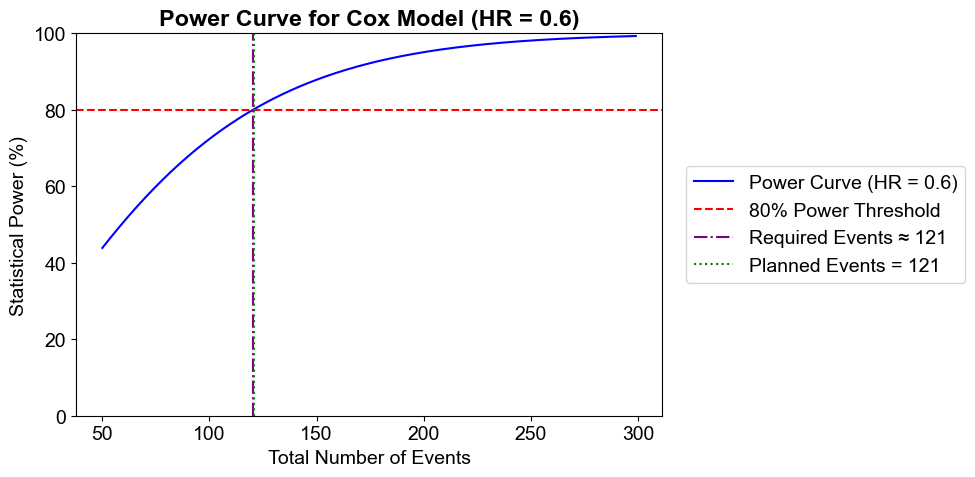

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set global font to Arial and size 14
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14

# Parameters
q0 = 0.5   # allocation to control
q1 = 0.5   # allocation to treatment
HR = 0.6   # hazard ratio
total_events_target = 121  # planned events
alpha = 0.05

# Z values
z_alpha = norm.ppf(1 - alpha / 2)
z_beta = norm.ppf(0.80)

# Event counts to explore
event_counts = np.arange(50, 300, 1)
powers = []

# Calculate power using Schoenfeld formula
for events in event_counts:
    se = 1 / np.sqrt(events * q0 * q1)
    z_effect = np.log(HR) / se
    power = 1 - (norm.cdf(z_effect - z_alpha) + (1 - norm.cdf(-z_effect - z_alpha)))
    powers.append(power * 100)

# Required events for 80% power
required_events = ((z_alpha + z_beta) ** 2) / ((np.log(HR)) ** 2 * q0 * q1)

# Create figure with two subplots (main plot + legend)
fig, (ax, ax_leg) = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [4, 1]})

# Main plot
ax.plot(event_counts, powers, color='blue', label=f'Power Curve (HR = {HR})')
ax.axhline(80, color='red', linestyle='--', label='80% Power Threshold')
ax.axvline(required_events, color='purple', linestyle='-.',
           label=f'Required Events ≈ {int(np.ceil(required_events))}')
ax.axvline(total_events_target, color='green', linestyle=':',
           label=f'Planned Events = {total_events_target}')

ax.set_xlabel('Total Number of Events')
ax.set_ylabel('Statistical Power (%)')
ax.set_title('Power Curve for Cox Model (HR = 0.6)', fontweight="bold")
ax.grid(False)
ax.set_ylim(0, 100)

# Legend subplot (turn off axes)
ax_leg.axis('off')
ax_leg.legend(*ax.get_legend_handles_labels(), loc='center')

plt.tight_layout()
plt.show()

fig.savefig('power_curve_cox_model_hr_0.6.png', dpi=300, bbox_inches='tight')


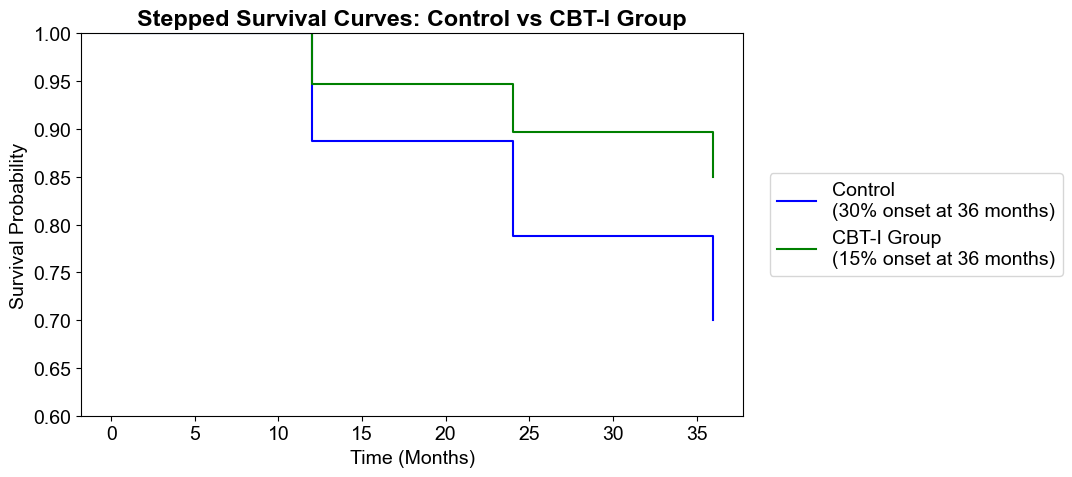

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Set global font to Arial
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14

# Time points in months
time_points = np.array([0, 12, 24, 36])

# Hazard rates from exponential assumption
lambda_control = -np.log(0.70) / 36  # 30% onset at 36 months → 70% survival
lambda_treatment = -np.log(0.85) / 36  # 15% onset at 36 months → 85% survival

# Survival probabilities
survival_control = np.exp(-lambda_control * time_points)
survival_treatment = np.exp(-lambda_treatment * time_points)

# Create figure with two subplots (main plot + legend)
fig, (ax, ax_leg) = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={'width_ratios': [4, 1]})

# Plot stepped survival curves
ax.step(time_points, survival_control, where='post', label='Control \n(30% onset at 36 months)', color='blue')
ax.step(time_points, survival_treatment, where='post', label='CBT-I Group \n(15% onset at 36 months)', color='green')

# Format
ax.set_xlabel('Time (Months)')
ax.set_ylabel('Survival Probability')
ax.set_title('Stepped Survival Curves: Control vs CBT-I Group', fontweight="bold")
ax.set_ylim(0.6, 1.0)   
ax.grid(False)

# Legend subplot (turn off axes)
ax_leg.axis('off')
ax_leg.legend(*ax.get_legend_handles_labels(), loc='center')
fig.savefig('stepped_survival_curves.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()
